# 01 · Exploratory Data Analysis

**Goal:** Understand what separates spam from ham before building any model. I want to identify the signals myself—such as email length and which words are indicative of spam versus ham—rather than making assumptions upfront. The insights I gain from this analysis will guide my feature engineering and modeling decisions.

In [2]:
%pip install matplotlib seaborn

     |████████████████████████████████| 7.9 MB 9.8 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 12.6 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 11.1 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 3.7 MB/s eta 0:00:011
     |████████████████████████████████| 2.4 MB 2.8 MB/s eta 0:00:011
     |████████████████████████████████| 265 kB 2.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/enron_spam_data.csv')
df.shape

(33716, 5)

In [4]:
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')

df.isnull().sum()

Message ID    0
Subject       0
Message       0
Spam/Ham      0
Date          0
dtype: int64

In [5]:
df['text'] = df['Subject'] + ' ' + df['Message']

df[['Subject', 'Message', 'text']].head()

,Subject,Message,text
0,christmas tree farm pictures,,christmas tree farm pictures
1,"vastar resources , inc .","gary , production from the high island larger ...","vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,calpine daily gas nomination - calpine daily g...
3,re : issue,fyi - see note below - already done .\nstella\...,re : issue fyi - see note below - already done...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,meter 7268 nov allocation fyi .\n- - - - - - -...


In [6]:
df['length'] = df['text'].str.len()

df.groupby('Spam/Ham')['length'].mean().round(1)

Spam/Ham
ham     1708.4
spam    1310.7
Name: length, dtype: float64

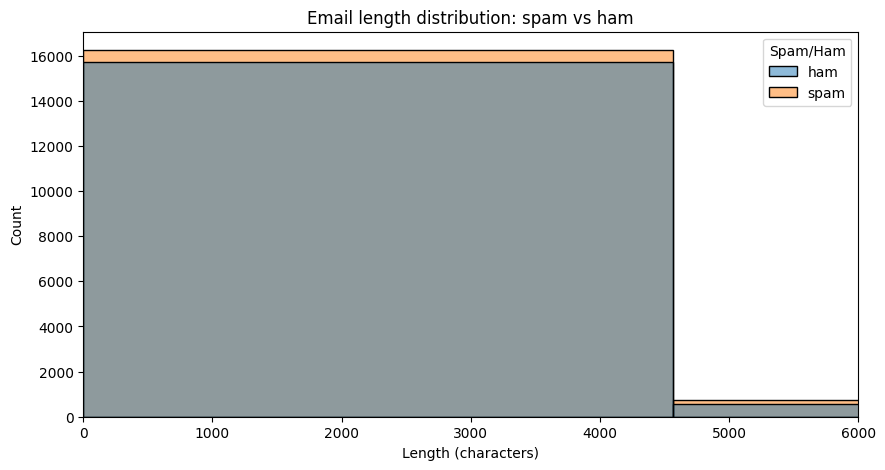

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length', hue='Spam/Ham', bins=50)
plt.xlim(0, 6000)
plt.title('Email length distribution: spam vs ham')
plt.xlabel('Length (characters)')
plt.show()

In [8]:
df['length'].describe()

count     33716.000000
mean       1505.897437
std        4283.381805
min           1.000000
25%         342.000000
50%         711.000000
75%        1553.000000
max      228368.000000
Name: length, dtype: float64

In [13]:
(df['length'] >= 6000).sum()

np.int64(1146)

In [11]:
(df['length'] >= 6000).mean().round(3)

np.float64(0.034)

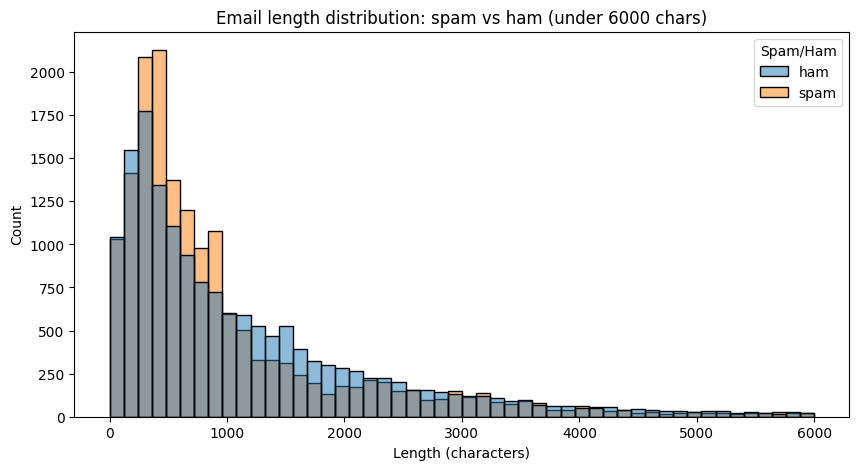

In [12]:
plt.figure(figsize=(10, 5))
subset = df[df['length'] < 6000]
sns.histplot(data=subset, x='length', hue='Spam/Ham', bins=50)
plt.title('Email length distribution: spam vs ham (under 6000 chars)')
plt.xlabel('Length (characters)')
plt.show()

### Length analysis

- Both spam and ham are right-skewed(most emails are short).
- Spam peaks in the 300-1000 char range; ham extends into longer lengths.
- Mean length: ham 1708,spam 1311—spam is shorter on average.
- Length is weak but usable signal,heavy overlap means it won't separate the classes alone.

In [14]:
spam_text = df[df['Spam/Ham'] == 'spam']['text']
ham_text = df[df['Spam/Ham'] == 'ham']['text']

print('spam emails:', len(spam_text))
print('ham emails:', len(ham_text))

spam emails: 17171
ham emails: 16545


In [16]:
from collections import Counter

spam_words = Counter(' '.join(spam_text).split())
ham_words = Counter(' '.join(ham_text).split())

print('Most common in SPAM:')
print(spam_words.most_common(20))

Most common in SPAM:
[('.', 242180), (',', 154180), ('the', 108442), ('-', 99338), ('to', 83331), ('and', 74064), ('of', 70848), ('_', 57656), (':', 53436), ('a', 52658), ('you', 47514), ('in', 45921), ('/', 45742), ('this', 34862), ('for', 34618), ('your', 33908), ('is', 33304), ('!', 32112), ('$', 23675), ("'", 23227)]


In [23]:
import re
from collections import Counter

def email_word(text):
    words = re.findall(r'[a-z]+', text.lower())
    return set(words)

spam_doc = Counter()
ham_doc = Counter()

for text in spam_text:
    for w in email_word(text):
        spam_doc[w] += 1

for text in ham_text:
    for w in email_word(text):
        ham_doc[w] += 1

print('done counting')

done counting


In [24]:
results = []
for w in spam_doc:
    spam_n = spam_doc[w]
    ham_n = ham_doc[w]
    total = spam_n + ham_n
    if total >= 200:
        spam_prob = spam_n / total
        results.append((w, spam_prob, total))

results.sort(key=lambda x: x[1], reverse=True)

print('Strongest SPAM signal words:')
for w, prob, total in results[:20]:
    print(f'{w:15} spam_prob={prob:.2f}  (appears in {total} emails)')

Strongest SPAM signal words:
vicodin         spam_prob=1.00  (appears in 211 emails)
pharmacy        spam_prob=1.00  (appears in 365 emails)
paliourg        spam_prob=1.00  (appears in 331 emails)
pills           spam_prob=1.00  (appears in 535 emails)
viagra          spam_prob=1.00  (appears in 1040 emails)
cialis          spam_prob=1.00  (appears in 616 emails)
photoshop       spam_prob=1.00  (appears in 504 emails)
valium          spam_prob=1.00  (appears in 271 emails)
erections       spam_prob=1.00  (appears in 233 emails)
xanax           spam_prob=1.00  (appears in 301 emails)
stationery      spam_prob=1.00  (appears in 384 emails)
serial          spam_prob=1.00  (appears in 353 emails)
unclaimed       spam_prob=1.00  (appears in 298 emails)
remitted        spam_prob=1.00  (appears in 279 emails)
ail             spam_prob=1.00  (appears in 340 emails)
rolex           spam_prob=1.00  (appears in 255 emails)
microcap        spam_prob=1.00  (appears in 220 emails)
dysfunction     sp

### Top spam signal words

- Strongest signals(spam_prob = 1.0): pharmacy/drug terms (viagra, vicodin, xanax),
  scam terms(unclaimed, microcap, rolex),pirated software(photoshop, serial).
- Notable:deliberate misspellings(couid->could, newsietter->newsletter, ail->mail)
  used to evade spam filters.Strong signal that real mail doesn't contain.
- 'paliourg' likely dataset-specific artifact,not true spam signal.

In [26]:
results_ham = []
for w in ham_doc:
    spam_n = spam_doc[w]
    ham_n = ham_doc[w]
    total = spam_n + ham_n
    if total >= 200:
        ham_prob = ham_n / total
        results_ham.append((w, ham_prob, total))

results_ham.sort(key=lambda x: x[1], reverse=True)

print('Strongest HAM signal words:')
for w, prob, total in results_ham[:20]:
    print(f'{w:15} ham_prob={prob:.2f}  (appears in {total} emails)')

Strongest HAM signal words:
calpine         ham_prob=1.00  (appears in 213 emails)
teco            ham_prob=1.00  (appears in 259 emails)
counterparty    ham_prob=1.00  (appears in 414 emails)
sitara          ham_prob=1.00  (appears in 453 emails)
mmbtu           ham_prob=1.00  (appears in 695 emails)
noms            ham_prob=1.00  (appears in 242 emails)
variances       ham_prob=1.00  (appears in 624 emails)
actuals         ham_prob=1.00  (appears in 283 emails)
dynegy          ham_prob=1.00  (appears in 245 emails)
ena             ham_prob=1.00  (appears in 818 emails)
enrononline     ham_prob=1.00  (appears in 396 emails)
ees             ham_prob=1.00  (appears in 483 emails)
ebs             ham_prob=1.00  (appears in 237 emails)
transwestern    ham_prob=1.00  (appears in 220 emails)
ferc            ham_prob=1.00  (appears in 345 emails)
whalley         ham_prob=1.00  (appears in 239 emails)
shankman        ham_prob=1.00  (appears in 209 emails)
counterparties  ham_prob=1.00  (appea

### Top ham signal words

- Strongest ham signals are all energy-industry and company-internal terms:
  company names (calpine, dynegy, teco),trading jargon (mmbtu, counterparty, ferc),
  employee names (whalley, lavorato, shankman).
- **Insight**: spam uses generic bait (viagra, rolex),ham uses organization-specific vocabulary.
- **Caveat**: many ham signals are Enron-specific,so the model may overfit to this company and generalize poorly to other inboxes.

## Takeaways

- 33,716 emails, roughly balanced (~51% spam). Balanced classes mean accuracy is reasonable starting metric.
- No missing labels — good, the data is ready for supervised learning.
- A small number of empty subjects/messages, which I'll fill in during preprocessing.
- Subject and body are separate columns, so I can combine them into one text field for modeling.